# Snow-Dominant Grid-Cell Classification via Logistic Regression

**Goal:** Classify precipitating grid cells over CONUS as *snow-dominant* vs
*non-snow-dominant* using ERA5 atmospheric predictors, then evaluate model
performance with standard classification metrics (accuracy, precision/recall,
ROC-AUC) and examine which variables are most strongly associated with
snow-dominant conditions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
)

%matplotlib inline
plt.rcParams.update({"font.size": 12, "figure.dpi": 120})

## 1. Load Data

In [2]:
df = pd.read_csv("stats_data/logistic_regression_data.csv.gz")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (2392668, 29)


,time,lon,lat,tp,ptype,t2m,d2m,dewpoint_depression,mslp,u10,...,wind_speed_850,vor_850,w_850,vapor_flux_850,Z_500,T_500,vor_500,w_500,thickness_1000_500,is_snow
0,2022-12-22 03:00:00,-129.00,20.0,0.000432,1,294.11870,288.51523,5.603485,1019.29810,-6.011078,...,3.649444,0.089710,0.271977,7.665856,587.58340,266.83972,-3.924500,0.040415,564.821486,0
1,2022-12-22 03:00:00,-128.75,20.0,0.001126,1,294.00153,288.68515,5.316376,1019.40063,-5.905609,...,3.554884,-0.062282,0.257573,8.106281,587.52730,266.79578,-3.888737,-0.033804,564.686658,0
2,2022-12-22 03:00:00,-128.50,20.0,0.001370,1,293.86480,288.83750,5.027313,1019.48315,-5.874359,...,3.227221,0.036065,0.208013,7.691498,587.46606,266.78796,-3.721844,-0.054800,564.565102,0
3,2022-12-22 03:00:00,-128.25,20.0,0.001239,1,293.73200,288.93906,4.792938,1019.52563,-5.840179,...,2.756883,0.012224,0.118657,6.609970,587.40990,266.78406,-3.641378,-0.047476,564.493568,0
4,2022-12-22 03:00:00,-128.00,20.0,0.000638,1,293.69293,288.87460,4.818329,1019.52814,-5.920258,...,2.356957,0.629132,0.073491,5.259986,587.38184,266.79870,-3.712904,-0.055288,564.466783,0


## 2. Define Features and Target

**Precipitation threshold** – We require `tp >= 0.01 in/hr` so that only
grid cells with meaningful precipitation enter the classifier (filtering out
trace amounts). Adjust `TP_THRESHOLD` to test sensitivity.

**Target** – Among the remaining cells, `snow_dominant = 1` when the ERA5
precipitation type indicates snow (`is_snow == 1`, i.e. ptype 5 or 6),
and `0` otherwise (rain, freezing rain, mixed).

In [3]:
TP_THRESHOLD = 0.01  # in/hr – adjust to test sensitivity

FEATURE_COLS = [
    # surface
    "t2m", "d2m", "dewpoint_depression", "mslp",
    "u10", "v10", "wind_speed_10m",
    "cape", "cin",
    # 850 hPa
    "T_850", "q_850", "rh_850",
    "u_850", "v_850", "wind_speed_850",
    "vor_850", "w_850", "vapor_flux_850",
    # 500 hPa
    "Z_500", "T_500", "vor_500", "w_500",
    # cross-level thermodynamic
    "thickness_1000_500",
]

TARGET_COL = "is_snow"
ALL_COLS = FEATURE_COLS + [TARGET_COL, "tp", "ptype"]

df_model = df[df["tp"] >= TP_THRESHOLD].copy()

# ── NaN diagnostics ─────────────────────────────────────────────────
nan_counts = df_model[ALL_COLS].isna().sum()
nan_any = nan_counts[nan_counts > 0]
n_before = len(df_model)

if nan_any.empty:
    print("No NaN values found in feature / target columns.")
else:
    print(f"NaN report  (rows before cleaning: {n_before:,d})")
    print("-" * 48)
    for col, cnt in nan_any.items():
        print(f"  {col:<25s}  {cnt:>8,d}  ({cnt / n_before * 100:5.2f}%)")
    total_nan_rows = df_model[ALL_COLS].isna().any(axis=1).sum()
    print("-" * 48)
    print(f"  {'Rows with any NaN':<25s}  {total_nan_rows:>8,d}  "
          f"({total_nan_rows / n_before * 100:5.2f}%)")

    df_model = df_model.dropna(subset=ALL_COLS).reset_index(drop=True)
    print(f"\n  Rows after dropping NaN: {len(df_model):,d}")

# ── Target ──────────────────────────────────────────────────────────
df_model["snow_dominant"] = (df_model["is_snow"] == 1).astype(int)

print(f"\nSamples after tp >= {TP_THRESHOLD} and NaN removal: {len(df_model):,d}")
print(f"Snow-dominant (1): {df_model['snow_dominant'].sum():,d}")
print(f"Non-snow     (0): {(df_model['snow_dominant'] == 0).sum():,d}")
print(f"Snow fraction:     {df_model['snow_dominant'].mean():.3f}")

NaN report  (rows before cleaning: 503,687)
------------------------------------------------
  cin                         444,078  (88.17%)
------------------------------------------------
  Rows with any NaN           444,078  (88.17%)

  Rows after dropping NaN: 59,609

Samples after tp >= 0.01 and NaN removal: 59,609
Snow-dominant (1): 1,142
Non-snow     (0): 58,467
Snow fraction:     0.019


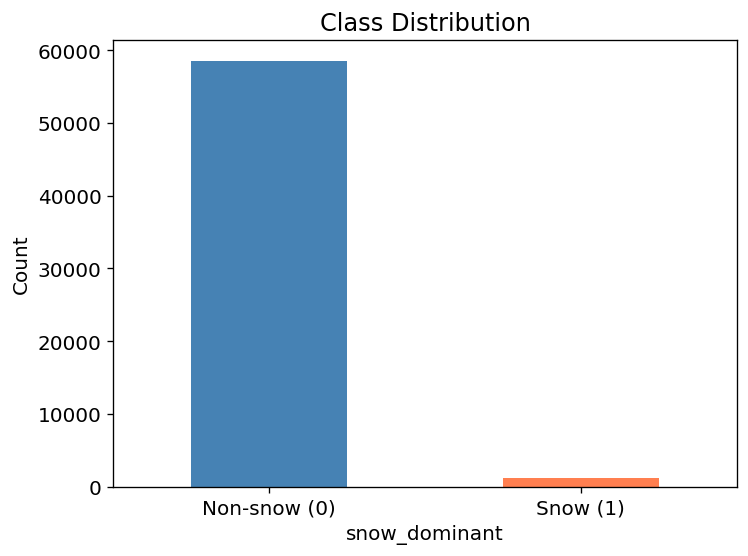

In [4]:
df_model["snow_dominant"].value_counts().plot.bar(color=["steelblue", "coral"])
plt.xticks([0, 1], ["Non-snow (0)", "Snow (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

## 3. Train / Test Split and Standardisation

In [5]:
X = df_model[FEATURE_COLS].values
y = df_model["snow_dominant"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]:,d}   Test: {X_test_sc.shape[0]:,d}")

Train: 44,706   Test: 14,903


## 4. Train Logistic Regression Model

In [6]:
model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42,
)
model.fit(X_train_sc, y_train)

print(f"Train accuracy: {model.score(X_train_sc, y_train):.4f}")
print(f"Test  accuracy: {model.score(X_test_sc, y_test):.4f}")

Train accuracy: 0.9913
Test  accuracy: 0.9912


## 5. Physical Interpretability – Standardised Coefficients

Because features are standardised (zero mean, unit variance), the logistic-
regression coefficients are directly comparable: a larger absolute value
means a stronger association with snow-dominant conditions (positive =
increases snow probability, negative = decreases it).

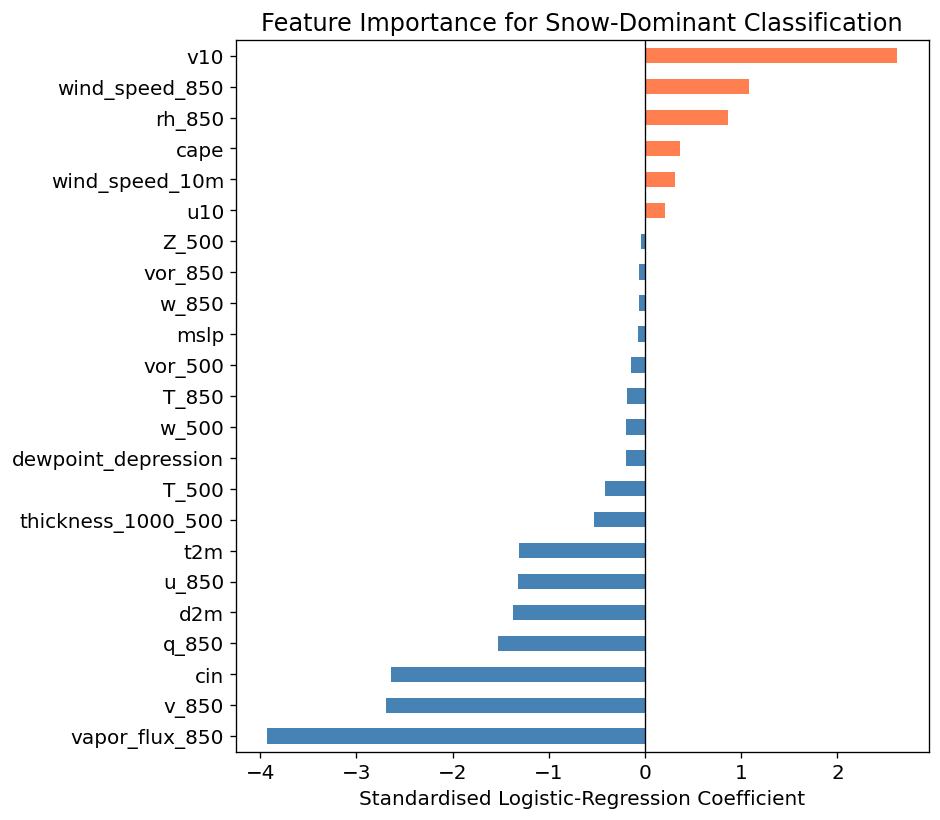


Top 5 predictors (by |coef|):
vapor_flux_850    3.926124
v_850             2.691810
cin               2.640123
v10               2.622918
q_850             1.523799


In [7]:
coefs = pd.Series(model.coef_[0], index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["steelblue" if c < 0 else "coral" for c in coefs]
coefs.plot.barh(ax=ax, color=colors)
ax.axvline(0, color="k", linewidth=0.8)
ax.set_xlabel("Standardised Logistic-Regression Coefficient")
ax.set_title("Feature Importance for Snow-Dominant Classification")
plt.tight_layout()
plt.show()

print("\nTop 5 predictors (by |coef|):")
print(coefs.abs().sort_values(ascending=False).head(5).to_string())

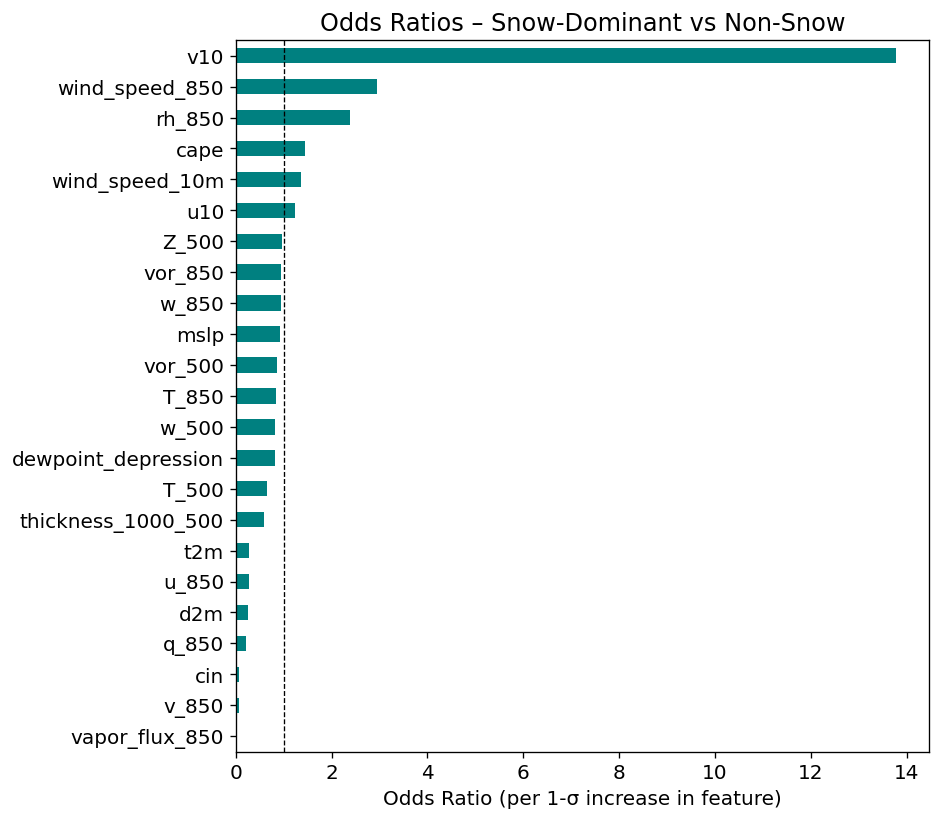

In [8]:
odds_ratios = np.exp(coefs)

fig, ax = plt.subplots(figsize=(8, 7))
odds_ratios.sort_values().plot.barh(ax=ax, color="teal")
ax.axvline(1, color="k", linewidth=0.8, linestyle="--")
ax.set_xlabel("Odds Ratio (per 1-σ increase in feature)")
ax.set_title("Odds Ratios – Snow-Dominant vs Non-Snow")
plt.tight_layout()
plt.show()

## 6. Classification Metrics – Confusion Matrix, Precision, Recall, F1

              precision    recall  f1-score   support

    Non-snow       1.00      0.99      1.00     14617
        Snow       0.69      1.00      0.81       286

    accuracy                           0.99     14903
   macro avg       0.84      1.00      0.90     14903
weighted avg       0.99      0.99      0.99     14903



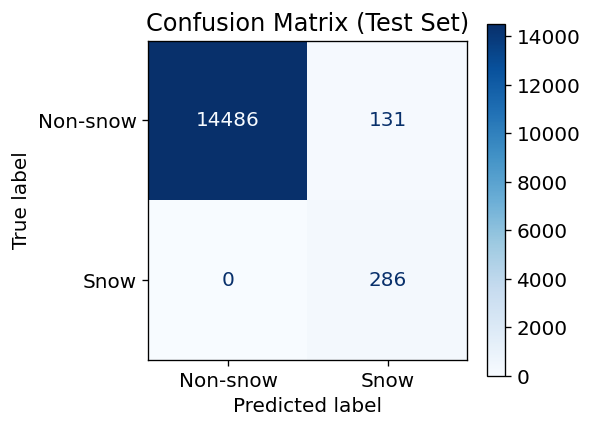

In [9]:
y_pred = model.predict(X_test_sc)

print(classification_report(y_test, y_pred,
                            target_names=["Non-snow", "Snow"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Non-snow", "Snow"],
    cmap="Blues", ax=ax,
)
ax.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

## 7. ROC Curve and AUC

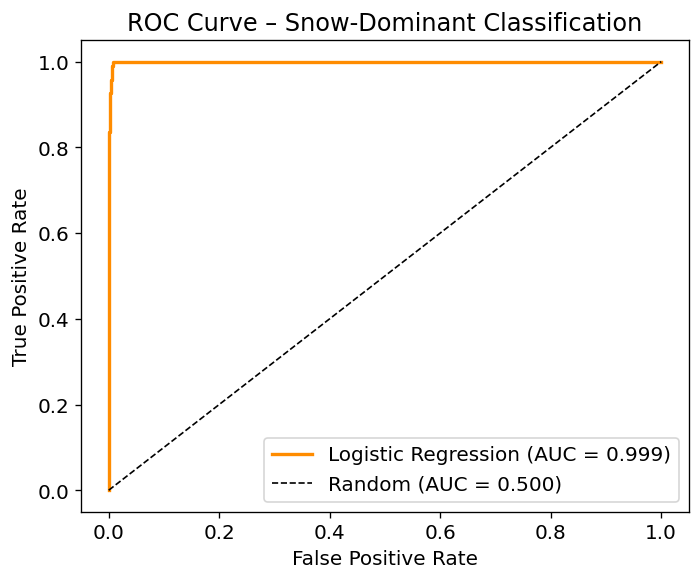

In [10]:
y_prob = model.predict_proba(X_test_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="darkorange", lw=2,
        label=f"Logistic Regression (AUC = {auc_val:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve – Snow-Dominant Classification")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Precision-Recall Curve

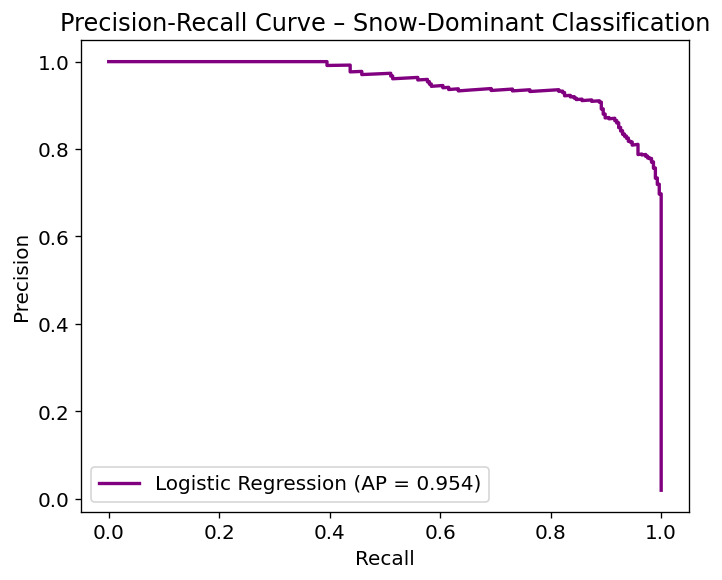

In [11]:
precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_arr, precision_arr, color="purple", lw=2,
        label=f"Logistic Regression (AP = {ap:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve – Snow-Dominant Classification")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 9. Summary

| Metric | Value |
|--------|-------|
| Test accuracy | printed above |
| ROC-AUC | printed above |
| Average precision | printed above |

**Key physical findings** (interpret after running):
- Features with the largest positive coefficients *favour* snow.
- Features with the largest negative coefficients *oppose* snow.
- The odds-ratio plot shows how much a 1-σ increase in each
  predictor multiplies the odds of the grid cell being snow-dominant.